# 04 — Búsqueda de hiperparámetros: red neuronal (MLP)

Un MLP feed-forward (PyTorch). Buscamos arquitectura y **regularización**:

- Arquitectura: `hidden_dims` (capas y anchos).
- Regularización: `dropout`, `weight_decay` (L2 vía el optimizador). Además, cada
  modelo hace *early stopping* sobre un split interno de validación.
- Optimización: `lr`.

La red estandariza el target internamente. Búsqueda aleatoria con la misma CV
temporal; el test se reserva para el final. (Menos combinaciones que XGBoost porque
cada entrenamiento es más caro.)

**Nota:** con solo unos miles de filas, una red poco regularizada sobreajusta con
ganas (memoriza el rinde medio de cada depto en train y no generaliza al test, que
además cae en años *fuera* del rango de train). Por eso la grilla apunta a redes
chicas y regularización fuerte — el `dropout` alto es el que más mueve la aguja.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))          # componente_b/ (datos, evaluacion)
warnings.filterwarnings('ignore')                  # silenciar ConvergenceWarning de sklearn

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

import datos, evaluacion as ev
from modelos import (LinearRegressor, XGBoostRegressor, NeuralNetRegressor,
                     RandomForestRegressorModel, HistGBMRegressor, StackingRegressorModel)

# Todo el análisis se hace sobre los DOS cultivos. El dataset "principal" usa las
# features agronómicas de ventana crítica (use_agro) y el suavizado del target
# encoding de depto (enc_smooth): la configuración que mejor generaliza.
CULTIVOS = ['soja', 'maiz']
DSS = {c: datos.prepare(c, use_agro=True, enc_smooth=10.0) for c in CULTIVOS}
for c in CULTIVOS:
    d = DSS[c]
    print(f'{c:5s}: {len(d.feature_cols)} features | '
          f'train {d.X_train.shape[0]} filas (≤{datos.TRAIN_END}) | '
          f'test {d.X_test.shape[0]} filas (≥{datos.TEST_START})')


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
soja : 78 features | train 7551 filas (≤2020) | test 942 filas (≥2021)
maiz : 78 features | train 9678 filas (≤2020) | test 1160 filas (≥2021)


## La búsqueda (para soja y maíz)

Búsqueda aleatoria de 14 combinaciones, optimizando RMSE de validación temporal, por cultivo.

In [2]:
grid = {
    'hidden_dims':  [(16,), (32,), (64, 32)],
    'dropout':      [0.1, 0.3, 0.5],
    'weight_decay': [1e-3, 1e-2, 3e-2],
    'lr':           [1e-3, 3e-3],
}
BEST_NN, TAB = {}, {}
for c in CULTIVOS:
    TAB[c], BEST_NN[c] = ev.buscar(NeuralNetRegressor, grid, DSS[c], metric='rmse',
                                   n_iter=14, random_state=42, n_splits=4,
                                   fixed={'max_epochs': 200, 'patience': 25, 'l1_lambda': 0.0})
    print(f'{c}: mejores HP = {BEST_NN[c]}')
TAB['soja'].head(8)

soja: mejores HP = {'hidden_dims': (64, 32), 'dropout': 0.1, 'weight_decay': 0.03, 'lr': 0.003}
maiz: mejores HP = {'hidden_dims': (64, 32), 'dropout': 0.5, 'weight_decay': 0.01, 'lr': 0.001}


,hidden_dims,dropout,weight_decay,lr,cv_rmse,cv_rmse_std
0,"(64, 32)",0.100,0.030,0.003,653.279,96.400
1,"(32,)",0.300,0.030,0.001,655.487,107.377
2,"(32,)",0.500,0.010,0.003,657.235,105.197
3,"(32,)",0.500,0.010,0.001,665.080,109.723
4,"(64, 32)",0.500,0.010,0.001,667.777,119.116
5,"(64, 32)",0.500,0.001,0.003,673.440,106.929
6,"(16,)",0.100,0.030,0.001,674.333,97.496
7,"(32,)",0.300,0.010,0.001,677.417,104.476


## Modelo final (ambos cultivos)

Reentrenamos con los mejores hiperparámetros sobre todo el train y evaluamos en el
test, para cada cultivo.

In [3]:
MODN = {}
filas = []
for c in CULTIVOS:
    d = DSS[c]
    MODN[c] = NeuralNetRegressor(**BEST_NN[c], l1_lambda=0.0, max_epochs=250, patience=30,
                                 random_state=42).fit(d.X_train, d.y_train)
    filas.append({'cultivo': c, **ev.evaluar('Red neuronal (final)', MODN[c].predict(d.X_test), d)})
    filas.append({'cultivo': c, **ev.evaluar('media x depto', ev.pred_media_depto(d), d)})
pd.DataFrame(filas)[['cultivo', 'modelo', 'mae', 'rmse', 'r2', 'smape']]

,cultivo,modelo,mae,rmse,r2,smape
0,soja,Red neuronal (final),520.040,664.559,0.248,24.015
1,soja,media x depto,593.307,708.357,0.145,27.169
2,maiz,Red neuronal (final),"1,596.273","2,019.356",-0.013,31.026
3,maiz,media x depto,"1,500.686","1,785.230",0.208,31.662


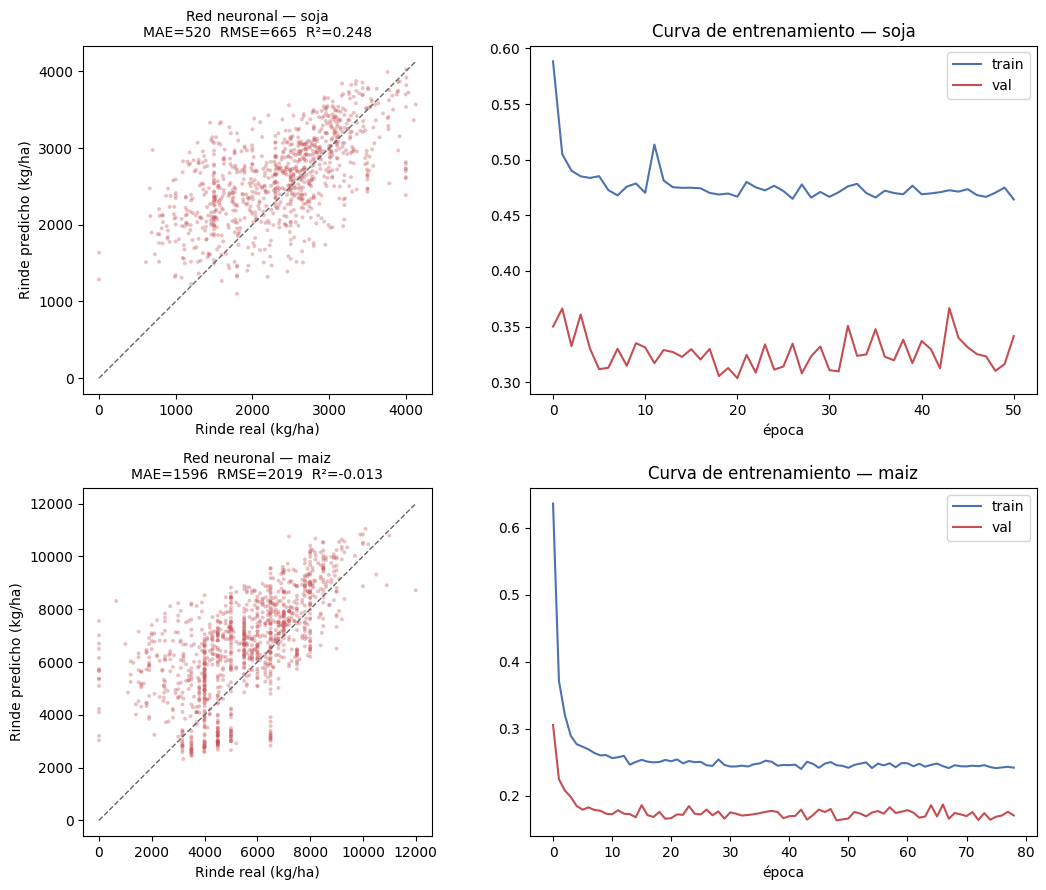

In [4]:
fig, axes = plt.subplots(len(CULTIVOS), 2, figsize=(11, 4.5 * len(CULTIVOS)))
for i, c in enumerate(CULTIVOS):
    d = DSS[c]
    ev.plot_pred_vs_real(d.y_test, MODN[c].predict(d.X_test), f'Red neuronal — {c}',
                         color=ev.C_NN, ax=axes[i, 0])
    h = MODN[c].history_
    axes[i, 1].plot(h['train_loss'], label='train', color=ev.C_LINEAR)
    if h['val_loss']:
        axes[i, 1].plot(h['val_loss'], label='val', color=ev.C_NN)
    axes[i, 1].set_title(f'Curva de entrenamiento — {c}'); axes[i, 1].set_xlabel('época'); axes[i, 1].legend()
plt.tight_layout(); plt.show()

## El mejor modelo del Componente A como features

Con la **configuración final ya elegida**, evaluamos en test el dataset (único,
unificado: clima + NDVI + ERA5) contra tres estrategias que reusan el **mejor
detector del Componente A** (el VAE `recon_prob`, que aprendió a representar el
clima "normal"): concatenar su **espacio latente**, hacer la regresión **solo en
el latente**, y agregar la categórica **`es_anomalo`** (su score umbralado).

El latente/score se computan en `latente.py` (y se cachean). *La primera corrida
entrena el VAE, así que tarda unos minutos.*

In [5]:
for c in CULTIVOS:
    print(f'=== {c} ===')
    display(ev.comparar_latente(NeuralNetRegressor, BEST_NN[c], c, fixed=dict(l1_lambda=0.0, max_epochs=250, patience=30, random_state=42),
                                vae_kwargs=dict(score_seeds=(42, 43, 44))))

=== soja ===
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,variante,n_feats,mae,rmse,r2,mape,smape
0,+ latente,90,460.376,584.901,0.417,23.915,21.766
1,+ es_anomalo,75,471.041,607.558,0.371,24.238,22.266
2,dataset unificado,74,539.101,681.350,0.209,31.140,24.577
3,solo latente,16,803.043,971.888,-0.609,33.731,37.237


=== maiz ===
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,variante,n_feats,mae,rmse,r2,mape,smape
0,+ latente,90,"1,499.073","1,917.626",0.087,38.421,30.091
1,+ es_anomalo,75,"1,551.041","1,984.074",0.022,39.893,31.186
2,dataset unificado,74,"1,656.263","2,076.716",-0.071,41.973,31.571
3,solo latente,16,"1,934.523","2,333.751",-0.353,36.084,39.858


## Conclusión

Con tan pocos miles de filas y features tabulares, la red neuronal compite pero no
suele destronar a un XGBoost bien tuneado. El notebook 05 compara las tres familias
más los baselines en igualdad de condiciones.